### Class

In [1]:
import cv2
import numpy as np
from PIL import Image

class ColorLocator():
    
    def __init__(self):
        self.colors_ref = [
            (0, 0, 0), (60, 60, 60), (120, 120, 120), (170, 170, 170), (210, 210, 210), (255, 255, 255), (96, 0, 24), (165, 14, 30), 
            (237, 28, 36), (250, 128, 114), (228, 92, 26), (255, 127, 39), (246, 170, 9), (249, 221, 59), (255, 250, 188), (156, 132, 49), 
            (197, 173, 49), (232, 212, 95), (74, 107, 58), (90, 148, 74), (132, 197, 115), (14, 185, 104), (19, 230, 123), (135, 255, 94), 
            (12, 129, 110), (16, 174, 166), (19, 225, 190), (15, 121, 159), (96, 247, 242), (187, 250, 242), (40, 80, 158), (64, 147, 228), 
            (125, 199, 255), (77, 49, 184), (107, 80, 246), (153, 177, 251), (74, 66, 132), (122, 113, 196), (181, 174, 241), (120, 12, 153), 
            (170, 56, 185), (224, 159, 249), (203, 0, 122), (236, 31, 128), (243, 141, 169), (155, 82, 73), (209, 128, 120), (250, 182, 164), 
            (104, 70, 52), (149, 104, 42), (219, 164, 99), (123, 99, 82), (156, 132, 107), (214, 181, 148), (209, 128, 81), (248, 178, 119), 
            (255, 197, 165), (109, 100, 63), (148, 140, 107), (205, 197, 158), (51, 57, 65), (109, 117, 141), (179, 185, 209)
        ]
        self.dimming = 0
        self.dimming_cache = 0
        self.set_dimming(0, True)
        self.cell_data  = None
        self.grid_data  = None
        self.loc_data   = None
        self.color_data = None
        self.cell_area_multiplier = (0.5, 2)
    
    def set_dimming(self, val: int, update: bool = True):
        self.dimming = self._cap(val, 0, 90)
        if not update: return
        self.colors = []
        for c in self.colors_ref:
            self.colors.append(
                tuple(
                    self._cap(int(x*(100-self.dimming)/100), 0, 255) for x in c
                )
            )
        self.dimming_cache = self.dimming
    
    def update_dimming(self):
        if self.dimming_cache == self.dimming: return
        self.set_dimming(self.dimming, True)
        
    def filter_cell_img(self, img: Image.Image, tol = 0, method = 'contours', specify_colors: list | None = None, exclude_colors: list = []):
        # 获取边框
        mask = self._mask_img(img, tol, specify_colors, exclude_colors)
        if method == 'contours':
            ret = self._get_rectangle_by_contours(mask)
            if ret != None:
                x, y, w, h, area = ret
            else: return None
        elif method == 'bounds':
            ret = self._get_rectangle_by_bounds(mask)
            if ret != None:
                x, y, w, h, area = ret
            else: return None
        else:
            raise ValueError("method 参数必须是 'contours' 或 'bounds'")
        
        # 读取中心像素
        center = (int(x) + int(w/2), int(y) + int(h/2))
        pixel = img.getpixel(center)
        return {
            'loc': (x, y, w, h),
            'area': area,
            'color': pixel
        }
        
    # 内部函数
    
    def _in_range(self, val, min_val, max_val):
        return val == self._cap(val, min_val, max_val)
        
    def _cap(self, val, min_val, max_val):
        return max(min(val, max_val), min_val)
    
    def _contours(self, mask):
        _, binary = cv2.threshold(mask, 240, 255, cv2.THRESH_BINARY)
        return cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
    def _get_rectangle_by_contours(self, mask):
        """使用轮廓检测方法"""
        contours, _ = self._contours(mask)
        if not contours:
            return None
        # 找到最大的轮廓（假设白色长方形是最大的白色区域）
        largest_contour = max(contours, key=cv2.contourArea)
        # 获取边界矩形
        x, y, w, h = cv2.boundingRect(largest_contour)
        area = cv2.contourArea(largest_contour)
        return x, y, w, h, area
    
    def _get_rectangle_by_bounds(self, mask):
        """使用边界检测方法"""
        # 二值化处理
        _, binary = cv2.threshold(mask, 240, 255, cv2.THRESH_BINARY)
        # 找到所有白色像素的位置
        white_pixels = np.where(binary == 255)
        if len(white_pixels[0]) == 0:
            return None
        # 计算边界
        min_y, max_y = np.min(white_pixels[0]), np.max(white_pixels[0])
        min_x, max_x = np.min(white_pixels[1]), np.max(white_pixels[1])
        x, y = min_x, min_y
        w    = max_x - min_x + 1
        h    = max_y - min_y + 1
        area = len(white_pixels[0])
        return x, y, w, h, area
    
    def _mask_img(self, img: Image.Image, tol = 0, specify_colors: list | None = None, exclude_colors: list = []):
        if len(exclude_colors) > 0 and specify_colors is not None:
            for c in exclude_colors:
                specify_colors.remove(c)
        
        color_list = specify_colors if specify_colors is not None else self.colors
        
        if img.mode == 'RGBA':
            img = img.convert('RGB')
        elif img.mode != 'RGB':
            img = img.convert('RGB')
            
        # 获取掩码图像
        img_array = np.array(img)
        # 创建掩码
        mask = np.zeros(img_array.shape[:2], dtype=bool)
        # 遍历
        for color in color_list:
            if tol == 0:
                color_mask = np.all(img_array == color, axis=2)
            else:
                diff = np.abs(img_array.astype(int) - np.array(color).astype(int))
                color_mask = np.all(diff <= tol, axis=2)
            mask |= color_mask

        result = np.zeros(img_array.shape[:2], dtype=np.uint8)
        result[mask] = 255
        return result.astype(np.uint8)
        # return Image.fromarray(result.astype(np.uint8))

### Test

In [2]:
loc = ColorLocator()
loc.set_dimming(0)

In [3]:
img = Image.open('analyze.png')
ret1 = loc.filter_cell_img(img)
ret1

In [4]:
img = Image.open('o2.png')
ret = loc._mask_img(img, tol=1)
# Image.fromarray(ret.astype(np.uint8))
c_list, _ = loc._contours(ret)

In [15]:
dict().get('a') == None

True

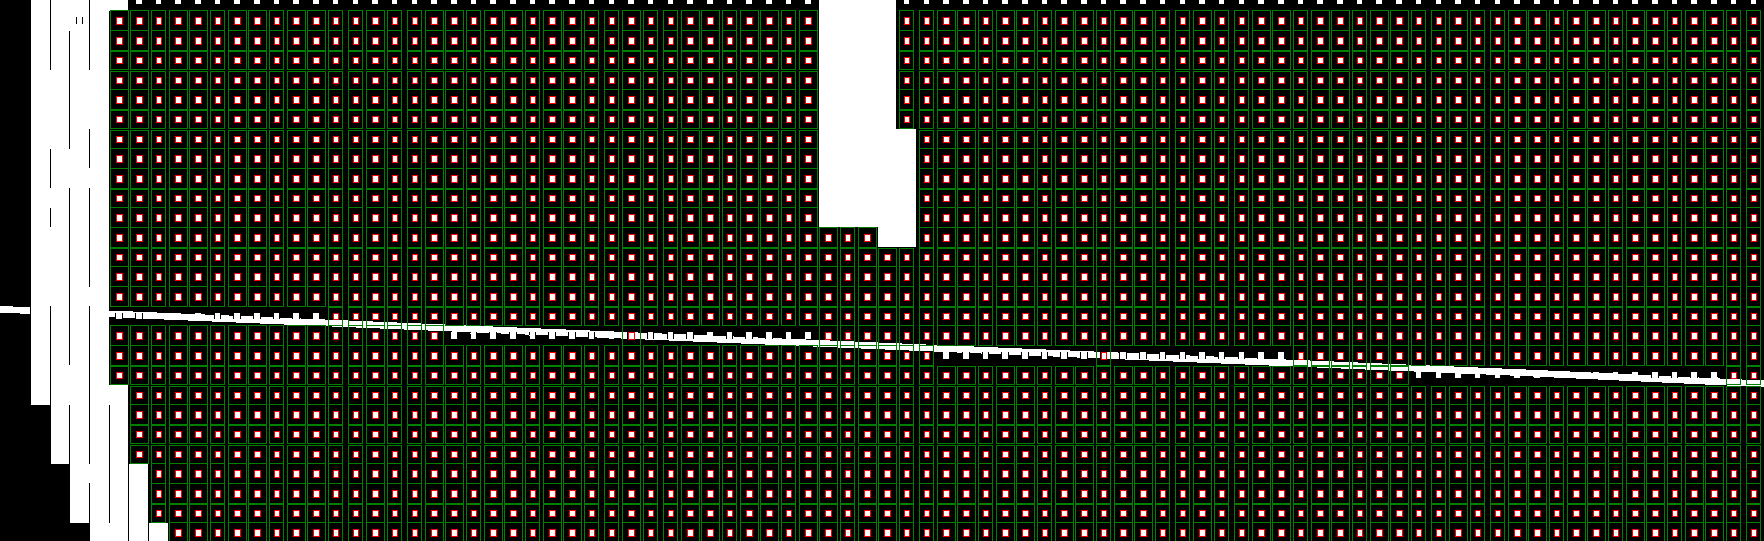

In [5]:
from PIL import ImageDraw

img_draw = Image.fromarray(ret.astype(np.uint8)).convert('RGB')
draw = ImageDraw.Draw(img_draw)

a_list = []
r_list = []

for c in c_list:
    x, y, w, h = cv2.boundingRect(c)
    
    # 转换为 PIL 的坐标格式 (left, top, right, bottom)
    left, top = x, y
    right, bottom = x + w, y + h
    
    cx, cy = int(x+w/2), int(y+h/2)
    
    if not loc._in_range(w*h, int(35*0.8), int(35*1.5)): continue
    if not loc._in_range(w/h, 0.7, 1.5): continue
    
    a_list.append(w*h)
    r_list.append(w/h)
    
    # 使用 ImageDraw.rectangle 绘制
    draw.rectangle([left, top, right, bottom], outline='red', width=1)
    draw.rectangle([cx - int(w*1.5), cy - int(h*1.5), cx + int(w*1.5), cy + int(h*1.5)], outline='green', width=1)
    
img_draw

In [6]:
a_list.sort()
a_list[int(len(a_list) * 0.9)]

b_list = []
for a in a_list:
    if a > 90: continue
    b_list.append(a)

In [7]:
max(r_list), min(r_list)

(1.0, 0.7142857142857143)

(array([ 515.,    0.,    0.,    0., 1088.,    0.,    0.,    0.,    0.,
         539.]),
 array([0.71428571, 0.74285714, 0.77142857, 0.8       , 0.82857143,
        0.85714286, 0.88571429, 0.91428571, 0.94285714, 0.97142857,
        1.        ]),
 <BarContainer object of 10 artists>)

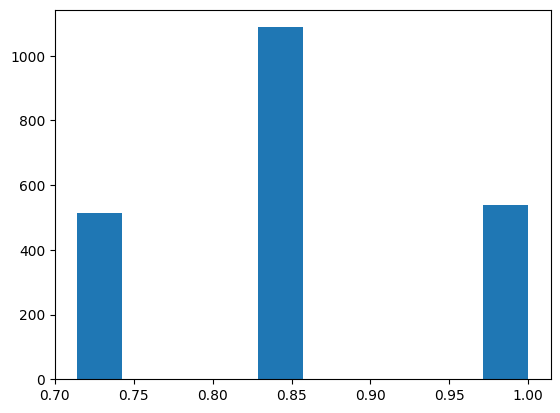

In [8]:
from matplotlib import pyplot

pyplot.hist(r_list)

In [13]:
0.7/1, 1/0.7

(0.7, 1.4285714285714286)

In [9]:
loc = ColorLocator()
loc.set_dimming(0)
img2 = Image.open('c.png')
ret2 = loc._mask_img(img2, tol=0, specify_colors=loc.colors_ref, exclude_colors=[(255, 255, 255)])
c_list2, _ = loc._contours(ret2)

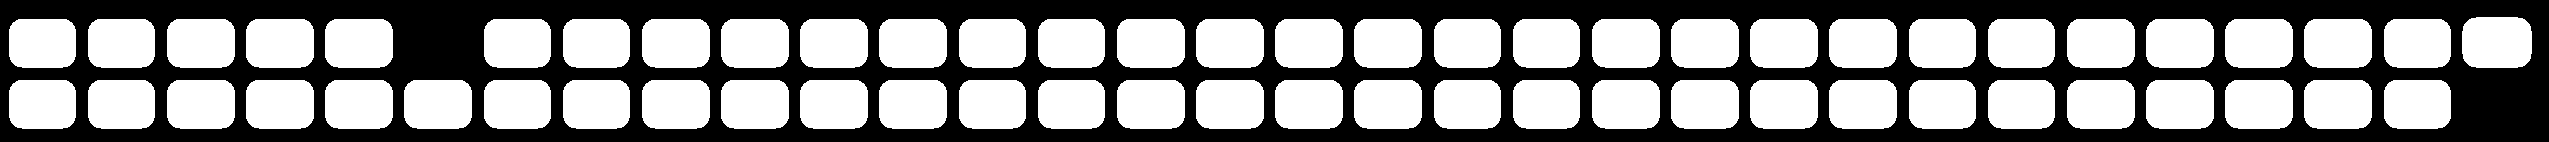

In [10]:
Image.fromarray(ret2.astype(np.uint8))

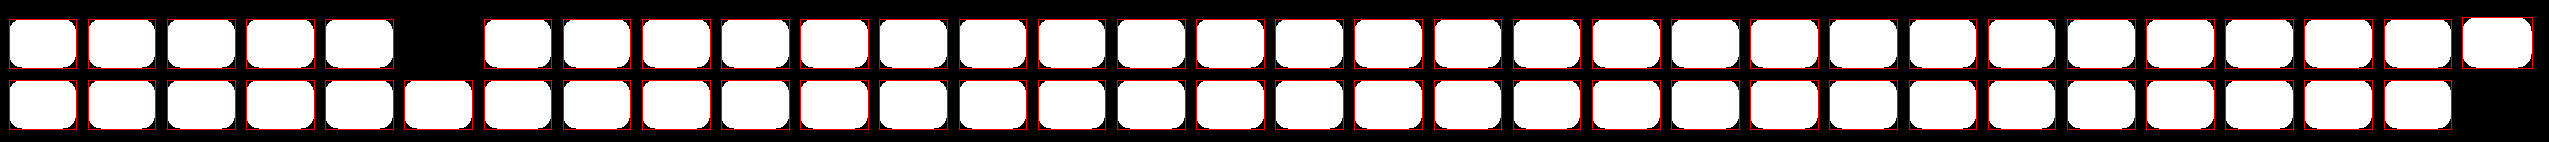

In [11]:
img2_draw = Image.fromarray(ret2.astype(np.uint8)).convert('RGB')
draw2 = ImageDraw.Draw(img2_draw)

for c in c_list2:
    x, y, w, h = cv2.boundingRect(c)
    
    # 转换为 PIL 的坐标格式 (left, top, right, bottom)
    left, top = x, y
    right, bottom = x + w, y + h
    
    cx, cy = int(x+w/2), int(y+h/2)
    
    # 使用 ImageDraw.rectangle 绘制
    draw2.rectangle([left, top, right, bottom], outline='red', width=1)
    
img2_draw

### Stand alone code

In [12]:
from PIL import Image
import numpy as np

def cap(val, min_val, max_val):
    return max(min(val, max_val), min_val)

def filter_image_by_colors(img: Image.Image, color_list, tolerance=0):
    """

    """
    
    # 如果是RGBA模式，转换为RGB
    if img.mode == 'RGBA':
        img = img.convert('RGB')
    elif img.mode != 'RGB':
        img = img.convert('RGB')
    
    img_array = np.array(img)
    result = np.zeros_like(img_array)
    # 创建掩码
    mask = np.zeros(img_array.shape[:2], dtype=bool)
    
    # 遍历
    for color in color_list:
        if tolerance == 0:
            color_mask = np.all(img_array == color, axis=2)
        else:
            diff = np.abs(img_array.astype(int) - np.array(color).astype(int))
            color_mask = np.all(diff <= tolerance, axis=2)
        mask |= color_mask
    

    result[mask] = [255, 255, 255]
    result_image = Image.fromarray(result.astype(np.uint8))
    
    return result_image

colors_ref = [
            (0, 0, 0), (60, 60, 60), (120, 120, 120), (170, 170, 170), (210, 210, 210), (255, 255, 255), (96, 0, 24), (165, 14, 30), 
            (237, 28, 36), (250, 128, 114), (228, 92, 26), (255, 127, 39), (246, 170, 9), (249, 221, 59), (255, 250, 188), (156, 132, 49), 
            (197, 173, 49), (232, 212, 95), (74, 107, 58), (90, 148, 74), (132, 197, 115), (14, 185, 104), (19, 230, 123), (135, 255, 94), 
            (12, 129, 110), (16, 174, 166), (19, 225, 190), (15, 121, 159), (96, 247, 242), (187, 250, 242), (40, 80, 158), (64, 147, 228), 
            (125, 199, 255), (77, 49, 184), (107, 80, 246), (153, 177, 251), (74, 66, 132), (122, 113, 196), (181, 174, 241), (120, 12, 153), 
            (170, 56, 185), (224, 159, 249), (203, 0, 122), (236, 31, 128), (243, 141, 169), (155, 82, 73), (209, 128, 120), (250, 182, 164), 
            (104, 70, 52), (149, 104, 42), (219, 164, 99), (123, 99, 82), (156, 132, 107), (214, 181, 148), (209, 128, 81), (248, 178, 119), 
            (255, 197, 165), (109, 100, 63), (148, 140, 107), (205, 197, 158), (51, 57, 65), (109, 117, 141), (179, 185, 209)
        ]

dimming = 20

colors = []
for c in colors_ref:
    colors.append(
        tuple(cap(int(x * (100-dimming) / 100), 0, 255) for x in c)
    )

img = Image.open('analyze.png')
filter_image_by_colors(img, colors)